In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost shap fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#loading all libraries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score, PrecisionRecallDisplay, roc_auc_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib

In [5]:
#loading data
data = pd.read_csv("creditcard.csv")
print(data.shape)
print(data.head(2))
print(data.info())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  

[2 rows x 31 columns]
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4  

In [6]:
#EDA
class_counts = data['Class'].value_counts()
print(class_counts)

fraud_ratio = class_counts[1] / class_counts.sum()
print(f'Fradulent fraction: {fraud_ratio:.5f} ')


Class
0    284315
1       492
Name: count, dtype: int64
Fradulent fraction: 0.00173 


Fraud amounts:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
Normal amounts
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


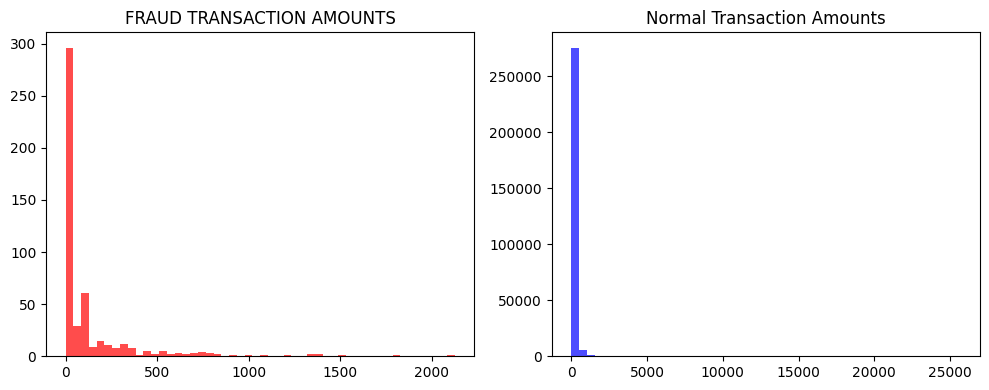

In [7]:
#transactions amounts by class
frauds = data[data['Class'] == 1]
normals = data[data['Class'] == 0]
print('Fraud amounts:') ; print(frauds['Amount'].describe())
print('Normal amounts') ; print(normals['Amount'].describe())

#visuals
plt.figure(figsize = (10, 4))
plt.subplot(1,2,1)
plt.hist(frauds['Amount'], bins=50, color='red', alpha=0.7)
plt.title('FRAUD TRANSACTION AMOUNTS')
plt.subplot(1,2,2)
plt.hist(normals['Amount'], bins=50, color='blue', alpha=0.7)
plt.title('Normal Transaction Amounts')
plt.tight_layout(); plt.show()

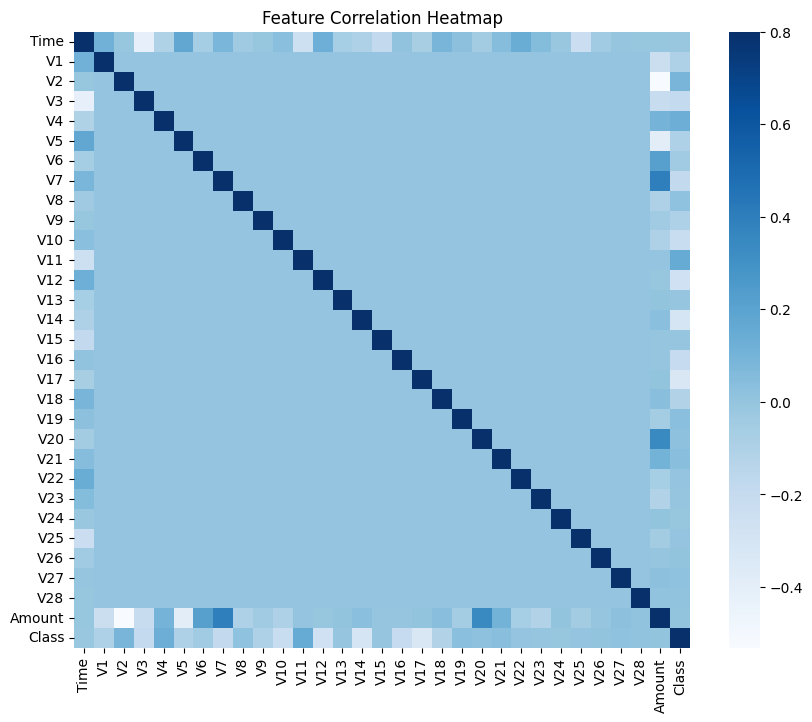

In [8]:
#correlation heatmap
corrmat = data.corr()
plt.figure(figsize = (10, 8))
sns.heatmap(corrmat, vmax = 0.8, square = True, cmap = 'Blues')
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
#Data preprocessing(Separating features and labels)
x = data.drop(['Class'], axis = 1)
y = data['Class']
print(x.shape, y.shape)

x_values = x.values
y_values = y.values

(284807, 30) (284807,)


In [10]:
#train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x_values, y_values,
    test_size = 0.2, random_state = 42, stratify = y_values
)
print(x_train.shape, x_test.shape)

(227845, 30) (56962, 30)


In [11]:
#feature scaling
scaler = StandardScaler()

#scale amount (col 29 ) and time(col 0)
x_train_scaled = x_train.copy().astype(float)
x_test_scaled = x_test.copy().astype(float)

x_train_scaled[:, 0] = scaler.fit_transform(x_train[:, [0]]).ravel()
x_test_scaled[:, 0] = scaler.transform(x_test[:, [0]]).ravel()

scaler2 = StandardScaler()
x_train_scaled[:, 29] = scaler2.fit_transform(x_train[:, [29]]).ravel()
x_test_scaled[:, 29] = scaler2.transform(x_test[:, [29]]).ravel()


In [12]:
#handling class imbalance with SMOTE
smote = SMOTE(random_state = 42)
x_train_sm, y_train_sm = smote.fit_resample(x_train_scaled, y_train)
print('Class distribution after SMOTE:')
print(pd.Series(y_train_sm).value_counts())
#both classes are equal

Class distribution after SMOTE:
0    227451
1    227451
Name: count, dtype: int64


In [14]:
#Model training(Logistic regression)
log_model =LogisticRegression(max_iter = 1000, random_state = 42)
log_model.fit(x_train_sm, y_train_sm)
y_pred_log = log_model.predict(x_test_scaled)
y_proba_log = log_model.predict_proba(x_test_scaled) [:, 1]

In [15]:
#Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42,
class_weight = 'balanced')
rf_model.fit(x_train_sm, y_train_sm)
y_pred_rf = rf_model.predict(x_test_scaled)
y_proba_rf = rf_model.predict_proba(x_test_scaled)[:, 1]

In [16]:
#xgboost
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators = 100,
    scale_pos_weight = fraud_weight,
    random_state = 42,
    eval_metric = 'aucpr',
   
)
xgb_model.fit(x_train_scaled, y_train)
y_pred_xgb =xgb_model.predict(x_test_scaled)
y_proba_xgb = xgb_model.predict_proba(x_test_scaled) [:, 1]

In [17]:
#cross validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_scores = cross_val_score(xgb_model, x_values, y_values, cv=cv,
                           scoring = 'average_precision')
print(f'Cross-Val AUC-PR: {cv_scores.mean() :.4f}(+/- {cv_scores.std() :.4f})')

Cross-Val AUC-PR: 0.8586(+/- 0.0309)


In [18]:
#Model evaluation and metrics
def evaluate_model(name, y_test, y_pred, y_proba):
    print(f'\n=== {name} ===')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
    print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-PR:    {average_precision_score(y_test, y_proba):.4f}')

evaluate_model('Logistic Regression', y_test, y_pred_log, y_proba_log)
evaluate_model('Random Forest',       y_test, y_pred_rf,  y_proba_rf)
evaluate_model('XGBoost',             y_test, y_pred_xgb, y_proba_xgb)


=== Logistic Regression ===
Accuracy:  0.9742
Precision: 0.0580
Recall:    0.9184
F1 Score:  0.1092
AUC-PR:    0.7249

=== Random Forest ===
Accuracy:  0.9995
Precision: 0.8454
Recall:    0.8367
F1 Score:  0.8410
AUC-PR:    0.8747

=== XGBoost ===
Accuracy:  0.9995
Precision: 0.8817
Recall:    0.8367
F1 Score:  0.8586
AUC-PR:    0.8800


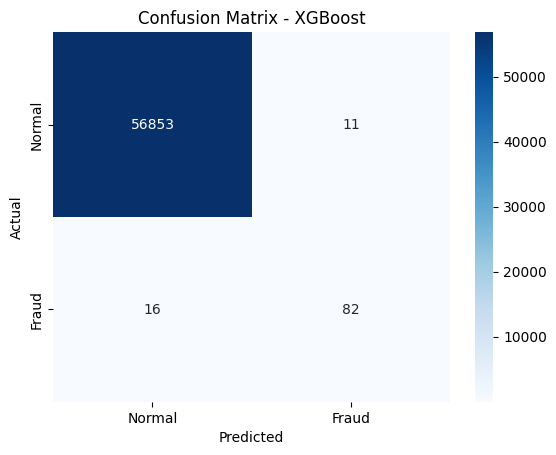

In [19]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
plt.xlabel('Predicted') ;plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

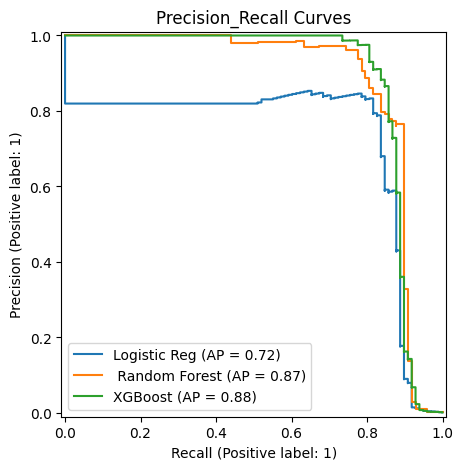

In [20]:
#Precision_Recall Curve
fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_log, name='Logistic Reg', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name=' Random Forest', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=ax)
plt.title('Precision_Recall Curves')
plt.show()


In [21]:
#Threshold Tuning
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    results.append({
        'threshold': t,
        'precision':precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0)
    })

results_df =pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  precision   recall       f1
      0.10   0.777778 0.857143 0.815534
      0.15   0.807692 0.857143 0.831683
      0.20   0.848485 0.857143 0.852792
      0.25   0.857143 0.857143 0.857143
      0.30   0.857143 0.857143 0.857143
      0.35   0.864583 0.846939 0.855670
      0.40   0.864583 0.846939 0.855670
      0.45   0.873684 0.846939 0.860104
      0.50   0.881720 0.836735 0.858639
      0.55   0.881720 0.836735 0.858639
      0.60   0.881720 0.836735 0.858639
      0.65   0.881720 0.836735 0.858639
      0.70   0.891304 0.836735 0.863158
      0.75   0.901099 0.836735 0.867725
      0.80   0.901099 0.836735 0.867725
      0.85   0.910112 0.826531 0.866310


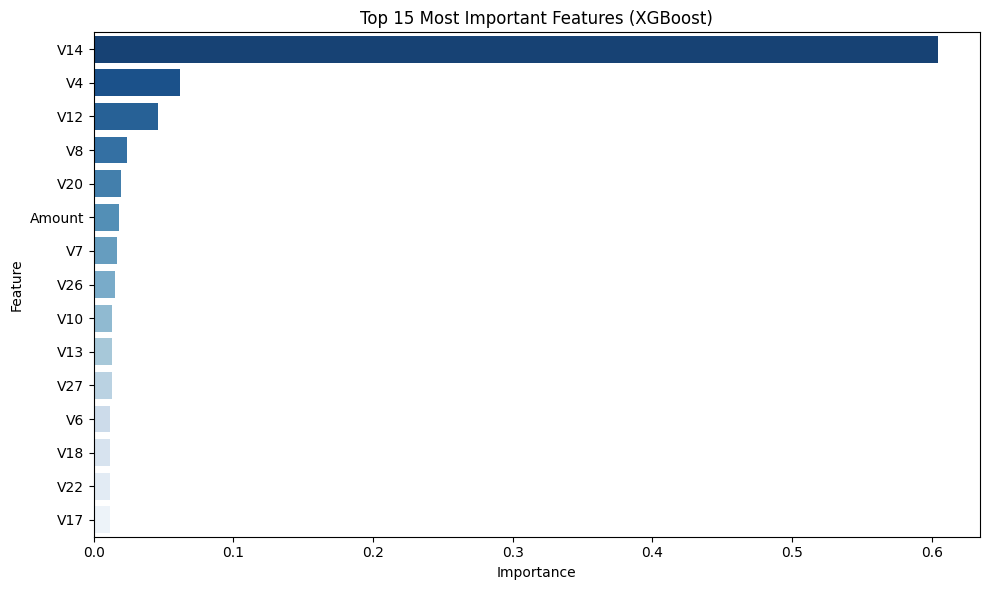

In [22]:
# Feature importance from XGBoost
feature_names = x.columns.tolist()
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, 
            hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 15 Most Important Features (XGBoost)')
plt.tight_layout()
plt.show()


In [23]:
# Save the best model and scalers
joblib.dump(xgb_model, 'fraud_model.pkl')
joblib.dump(scaler,    'scaler_time.pkl')
joblib.dump(scaler2,   'scaler_amount.pkl')
print('Model saved successfully.')


Model saved successfully.


In [24]:
#Load later
import joblib
xgb_model = joblib.load('fraud_model.pkl')
scaler     = joblib.load('scaler_time.pkl')
scaler2    = joblib.load('scaler_amount.pkl')

              Model  Accuracy  Precision  Recall  F1 Score  AUC-PR
Logistic Regression    0.9742     0.0580  0.9184    0.1092  0.7249
      Random Forest    0.9995     0.8454  0.8367    0.8410  0.8747
            XGBoost    0.9995     0.8817  0.8367    0.8586  0.8800


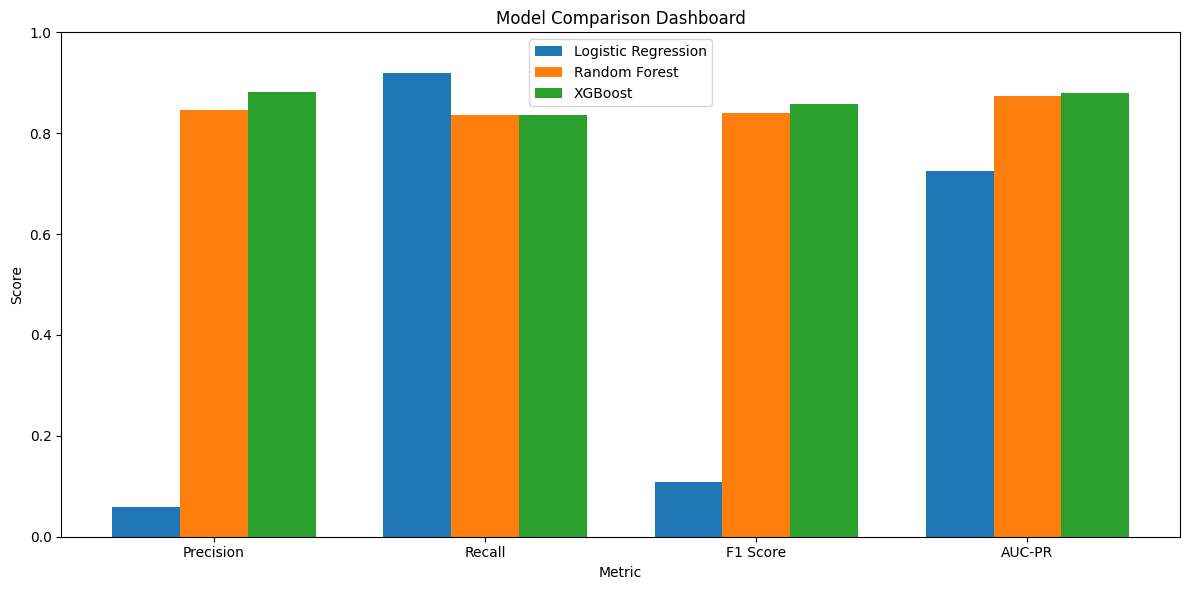

In [25]:
comparison_data ={
    'Model':['Logistic Regression','Random Forest', 'XGBoost'],
    'Accuracy':[accuracy_score(y_test, y_pred_log),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_log),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_log),
                  recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_xgb)],
    'F1 Score':  [f1_score(y_test, y_pred_log),
                  f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_xgb)],
    'AUC-PR':    [average_precision_score(y_test, y_proba_log),
                  average_precision_score(y_test, y_proba_rf),
                  average_precision_score(y_test, y_proba_xgb)]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

# Highlight the best value in each column
print(comparison_df.to_string(index=False))

# Visual bar chart
metrics = ['Precision', 'Recall', 'F1 Score', 'AUC-PR']
x = range(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(comparison_df.iterrows()):
    ax.bar([pos + i*width for pos in x], [row[m] for m in metrics],
           width, label=row['Model'])

ax.set_xlabel('Metric'); ax.set_ylabel('Score')
ax.set_title('Model Comparison Dashboard')
ax.set_xticks([pos + width for pos in x])
ax.set_xticklabels(metrics)
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

Optimal threshold: 0.05
Total cost at optimal threshold: $2720
False Negatives (missed fraud): 12
False Positives (blocked legit): 32


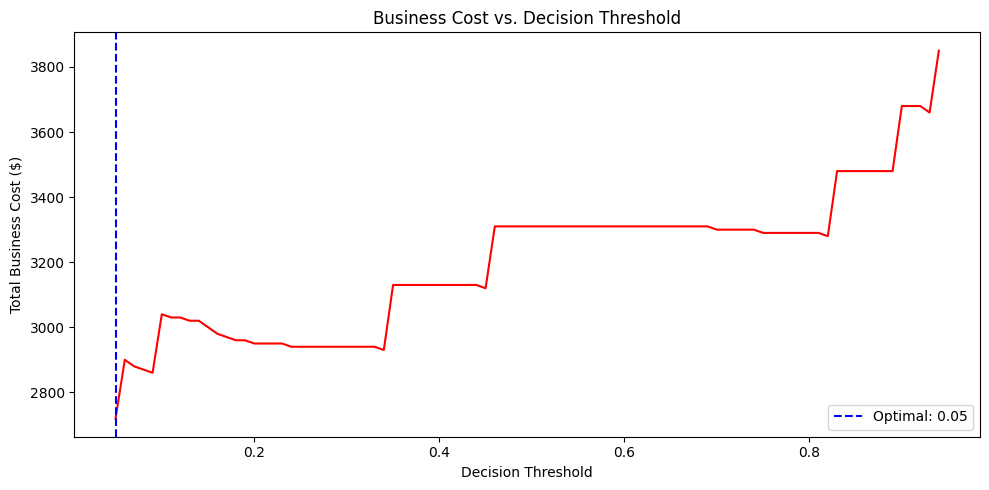

In [26]:
# Define costs (adjust these to your real business values)
COST_FALSE_NEGATIVE = 200   # avg loss when fraud is missed ($)
COST_FALSE_POSITIVE = 10    # cost of blocking a good transaction ($)

thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    costs.append({'threshold': t, 'total_cost': total_cost,
                  'false_negatives': fn, 'false_positives': fp})

cost_df = pd.DataFrame(costs)
optimal = cost_df.loc[cost_df['total_cost'].idxmin()]
print(f'Optimal threshold: {optimal["threshold"]:.2f}')
print(f'Total cost at optimal threshold: ${optimal["total_cost"]:.0f}')
print(f'False Negatives (missed fraud): {optimal["false_negatives"]:.0f}')
print(f'False Positives (blocked legit): {optimal["false_positives"]:.0f}')

# Plot cost curve
plt.figure(figsize=(10, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'], color='red')
plt.axvline(optimal['threshold'], color='blue', linestyle='--',
            label=f'Optimal: {optimal["threshold"]:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Business Cost ($)')
plt.title('Business Cost vs. Decision Threshold')
plt.legend(); plt.tight_layout(); plt.show()


In [27]:
def preprocess_transaction(transaction_dict, scaler_time, scaler_amount):
    """Prepare a single raw transaction for the model."""
    df = pd.DataFrame([transaction_dict])
    df['Time']   = scaler_time.transform(df[['Time']])
    df['Amount'] = scaler_amount.transform(df[['Amount']])
    return df.values


def predict_transaction(transaction_dict, model, scaler_time, scaler_amount,
                         threshold=0.5):
    """Score a single transaction and return fraud probability + verdict."""
    x_input = preprocess_transaction(transaction_dict, scaler_time, scaler_amount)
    proba = model.predict_proba(x_input)[0][1]
    verdict = 'FRAUD' if proba >= threshold else 'LEGITIMATE'
    print(f'Fraud Probability : {proba:.4f} ({proba*100:.1f}%)')
    print(f'Verdict           : {verdict}')
    return proba, verdict


# Example: simulate a new incoming transaction
new_transaction = {
    'Time': 40000, 'V1': -1.36, 'V2': -0.07, 'V3': 2.54, 'V4': 1.38,
    'V5': -0.34, 'V6': 0.46, 'V7': 0.24, 'V8': 0.10, 'V9': 0.36,
    'V10': 0.09, 'V11': -0.55, 'V12': -0.62, 'V13': -0.99, 'V14': -0.31,
    'V15': 1.47, 'V16': -0.47, 'V17': 0.21, 'V18': 0.03, 'V19': 0.40,
    'V20': 0.25, 'V21': -0.02, 'V22': 0.28, 'V23': -0.11, 'V24': 0.07,
    'V25': 0.13, 'V26': -0.19, 'V27': 0.13, 'V28': -0.02,
    'Amount': 149.62
}

proba, verdict = predict_transaction(
    new_transaction, xgb_model, scaler, scaler2, threshold=0.4
)


Fraud Probability : 0.0000 (0.0%)
Verdict           : LEGITIMATE


C:\Users\Matthew .K. Maunga\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\Matthew .K. Maunga\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [28]:
X = data.drop(['Class'], axis=1)

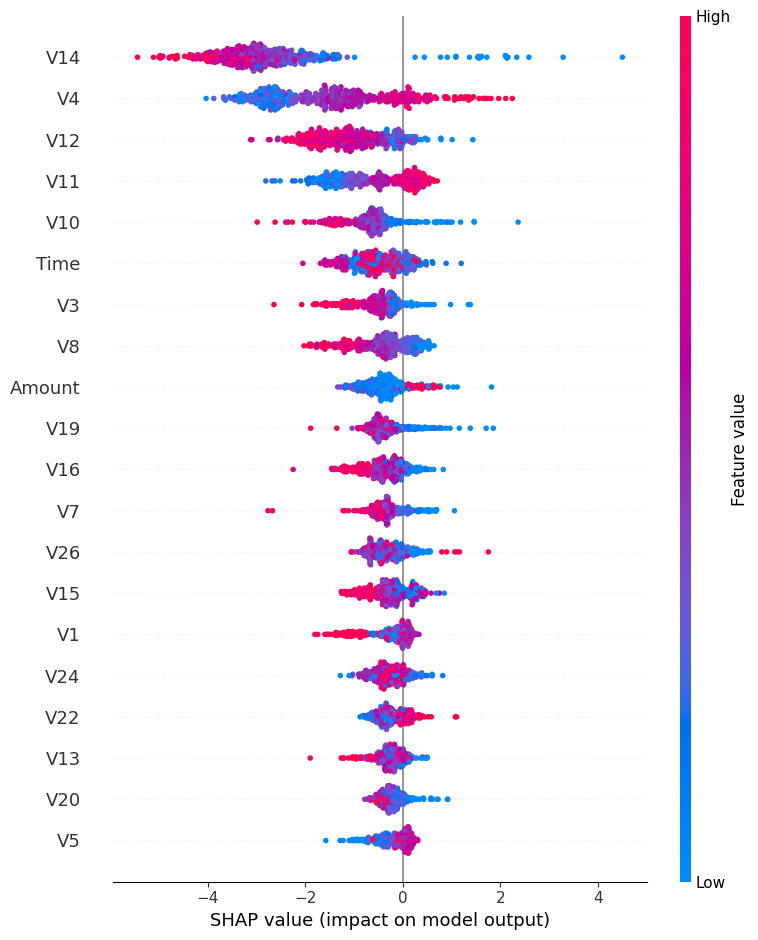

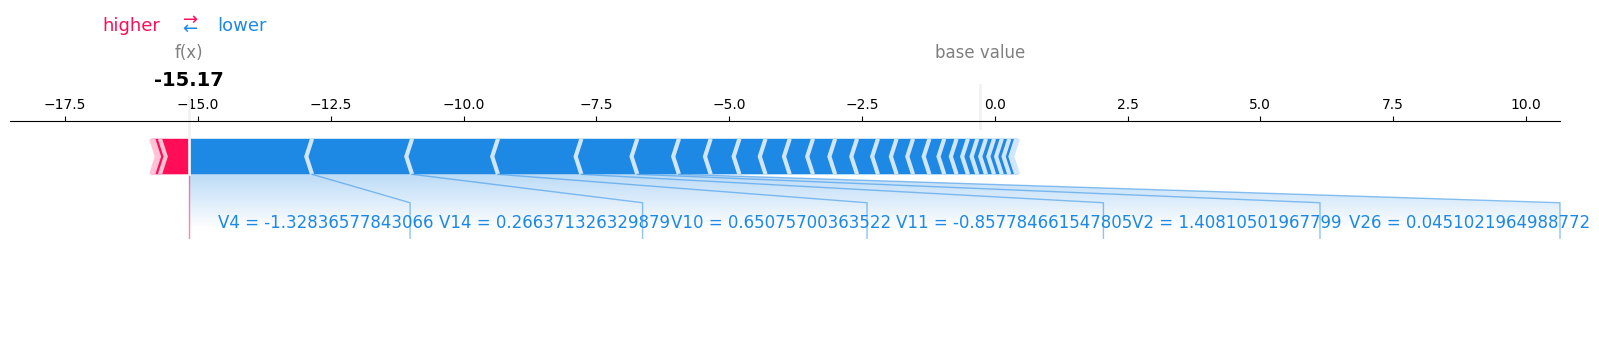

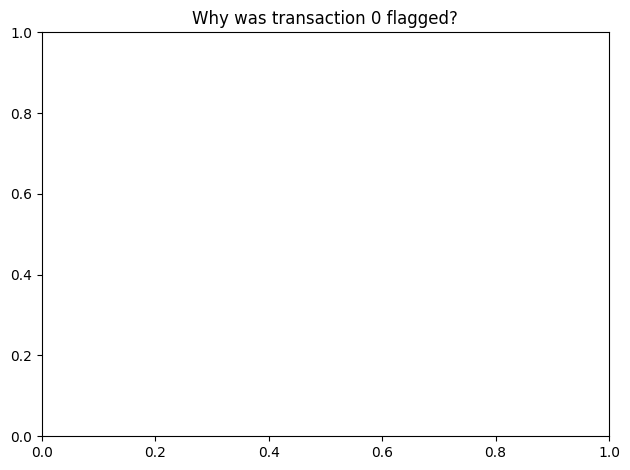

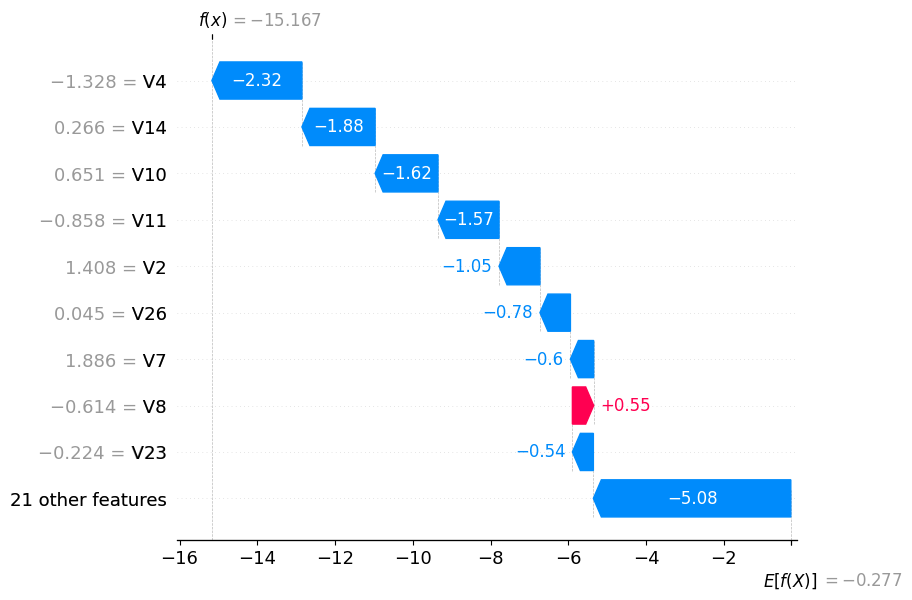

In [29]:
# Create a SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Explain predictions on the test set (use a sample for speed)
x_test_sample = x_test_scaled[:500]
shap_values = explainer.shap_values(x_test_sample)

#Summary — which features matter most overall 
shap.summary_plot(shap_values, x_test_sample, feature_names=X.columns.tolist())

#Explain ONE specific transaction 
transaction_index = 0   # change to any index you want to explain
shap.force_plot(
    explainer.expected_value,
    shap_values[transaction_index],
    x_test_sample[transaction_index],
    feature_names=X.columns.tolist(),
    matplotlib=True
)
plt.title(f'Why was transaction {transaction_index} flagged?')
plt.tight_layout(); plt.show()

#Waterfall — step-by-step explanation 
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[transaction_index],
        base_values=explainer.expected_value,
        data=x_test_sample[transaction_index],
        feature_names=X.columns.tolist()
    )
)
